In [1]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import pickle

In [2]:
from util import calc_deltas
deltas = calc_deltas(recompute=False)

In [25]:
from copy import deepcopy
def binnings(deltas : dict, anchor_percentile : int = 50, delta_percentile : int = 50) -> dict:
    """
        We're binning the deltas based on their likelihoods. We're binning
        per-checkpoint to counteract preference shift during training.

        output are samples of the intersection of
        - the high-bins for anchors per behaviour (high likelihood ground truth responses) 
        - the low-bins for distance between anchor and augmentation. (reasonable likelihoods of augmentation being sampled)

        This aims at removing noise in the augmentations and counteract preference shift.
    """

    # iterate over deltas, build clone
    clone = deepcopy(deltas)
    for method, checkpoints in deltas.items():
        for checkpoint, taxonomies in checkpoints.items():
            for taxonomy_name, taxonomy in taxonomies.items():
                for behaviour, values in taxonomy.items():
                    if behaviour == 'anchor':
                        continue
                
                    if taxonomy_name=='error_types': # for error types, anchors are split across behaviours.
                        anchor_dictionary = taxonomy['anchor'].item()
                        anchor = np.array(anchor_dictionary[behaviour])
                    else:
                        anchor = taxonomy['anchor']

                    top_percentile = np.percentile(anchor, anchor_percentile)
                    high_indices = (anchor >= top_percentile).squeeze()
                    bottom_percentile = np.percentile(values, delta_percentile)
                    low_indices = values <= bottom_percentile
                    intersection = high_indices & low_indices
                    clone[method][checkpoint][taxonomy_name][behaviour] = values[intersection]

                del clone[method][checkpoint][taxonomy_name]['anchor']
    return clone

def binnings_old(
    deltas: dict,
    anchor_min_lp: float = -3.0,
    delta_bins: tuple[float, float] = (0.0, 1.0),
) -> dict:
    """
    Selection logic (per checkpoint):
    - Anchor must have sufficiently high absolute likelihood
      (anchor >= anchor_min_lp)
    - Delta magnitude must fall within a fixed absolute bin:
        delta_bins[0] <= |Δlogp| < delta_bins[1]
    """

    clone = deepcopy(deltas)

    for method, checkpoints in deltas.items():
        for checkpoint, taxonomies in checkpoints.items():
            for taxonomy_name, taxonomy in taxonomies.items():
                for behaviour, values in taxonomy.items():
                    if behaviour == "anchor":
                        continue

                    # Resolve anchor values
                    if taxonomy_name == "error_types":
                        anchor_dict = taxonomy["anchor"].item()
                        anchor = np.array(anchor_dict[behaviour])
                    else:
                        anchor = np.asarray(taxonomy["anchor"])

                    # Binning in absolute terms
                    values = np.asarray(values)
                    anchor_mask = (anchor >= anchor_min_lp).squeeze()
                    delta_abs = np.abs(values)
                    delta_mask = (
                        (delta_abs >= delta_bins[0]) &
                        (delta_abs < delta_bins[1])
                    ).squeeze()
                    intersection = anchor_mask & delta_mask

                    clone[method][checkpoint][taxonomy_name][behaviour] = values[intersection]

                # Remove anchor after processing
                del clone[method][checkpoint][taxonomy_name]["anchor"]

    return clone

In [26]:
from collections import defaultdict

def preprocess(
    data: dict,
    methods: list[str] | None = None,
    models: list[str] | None = None,
    taxs: list[str] | None = None,
):
    """
    Reshape data for plotting.

    Output structure:
        taxonomy -> category -> method -> list[per-checkpoint means]
    """

    # taxonomy -> category -> method -> [values]
    result = defaultdict(
        lambda: defaultdict(lambda: defaultdict(list))
    )

    for key, checkpoints in data.items():
        model, method = key.split('__')

        if methods and method not in methods:
            continue
        if models and model not in models:
            continue

        for cp, taxonomies in checkpoints.items():
            for tax_name, categories in taxonomies.items():
                if taxs and tax_name not in taxs:
                    continue

                # compute per-checkpoint mean per category
                for category, values in categories.items():
                    result[tax_name][category][key].append(
                        np.mean(values)
                    )

    return result

In [27]:
models, methods = zip(*[x.split('__') for x in deltas.keys()])
models, methods = set(models), set(methods)

In [28]:
import matplotlib.pyplot as plt
from math import ceil
method_color_mapper = {
    k : color for k, color in zip(methods, plt.get_cmap("tab10").colors)
}
model_marker_mapper = {
    m : marker for m, marker in zip(models, ['*', '+', '^', 'o'])
}

def plot_helper(data):
    categories = list(data.keys())
    nrows, ncols = 2, ceil(len(categories) / 2)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3*ncols, 5))

    for ax, (category, model_method_dict) in zip(axes.flatten(), data.items()):

        # plot for current category
        for model_method, values in model_method_dict.items():
            model, method = model_method.split('__')
            color, marker = method_color_mapper[method], model_marker_mapper[model]
            xs = np.arange(len(values)) * 10
            ax.plot(xs, values, marker=marker, color=color, label=f'Model: {model}, Method: {method}')
        ax.set_title(category)
    plt.legend()
    plt.show()

/tmp/ipykernel_36950/3977211751.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


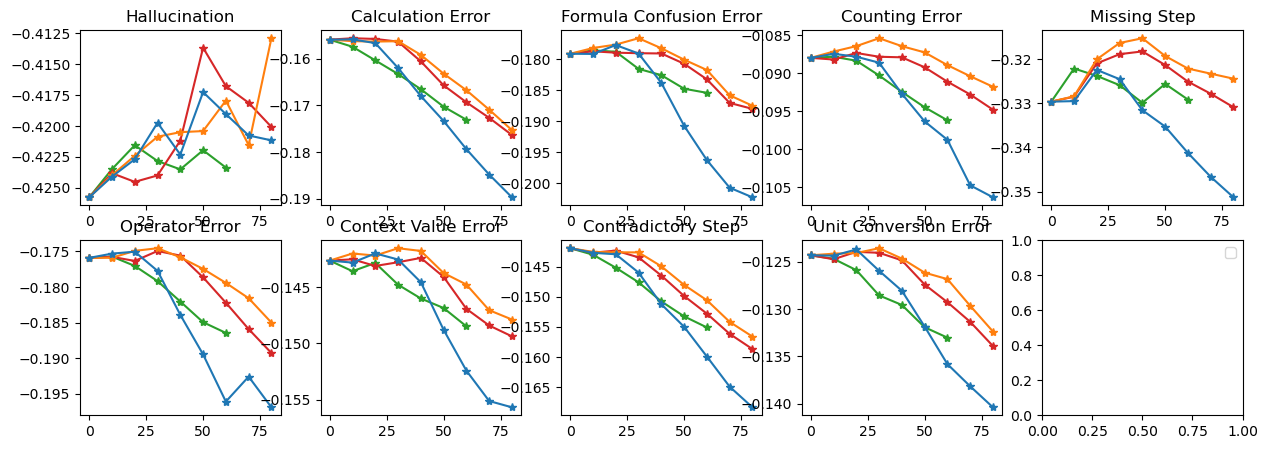

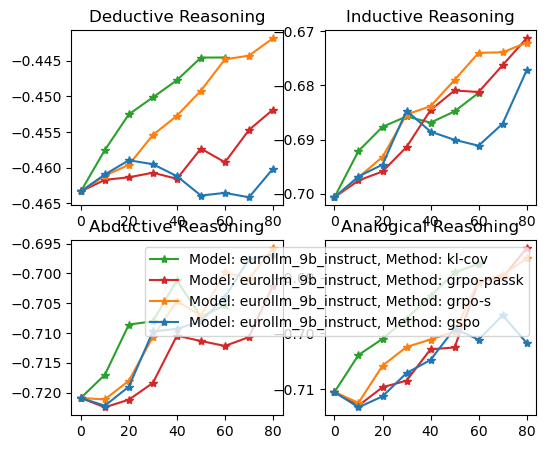

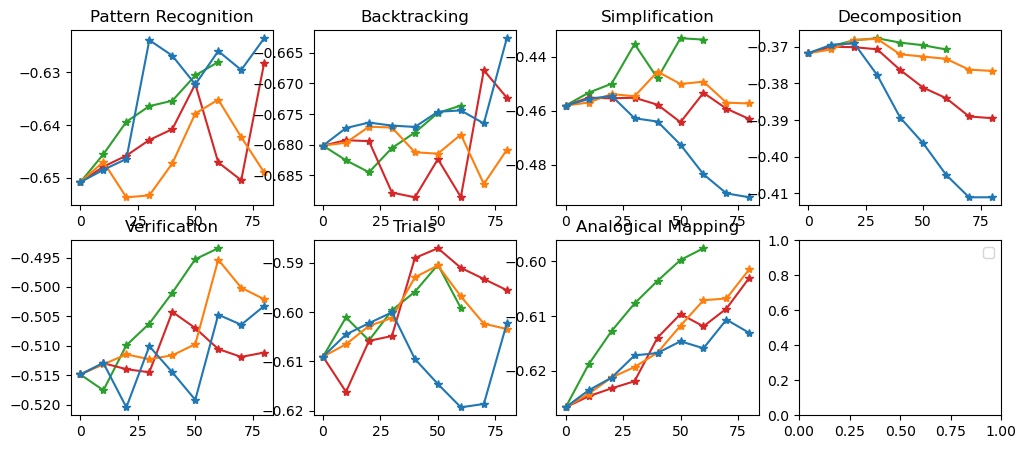

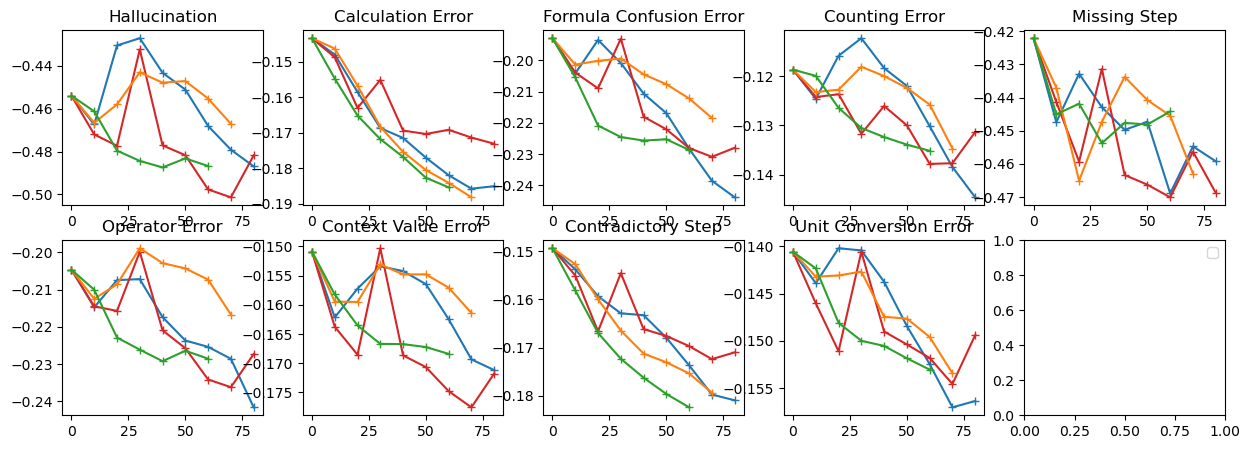

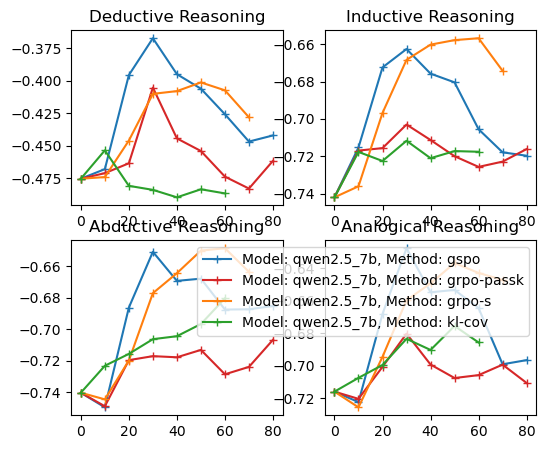

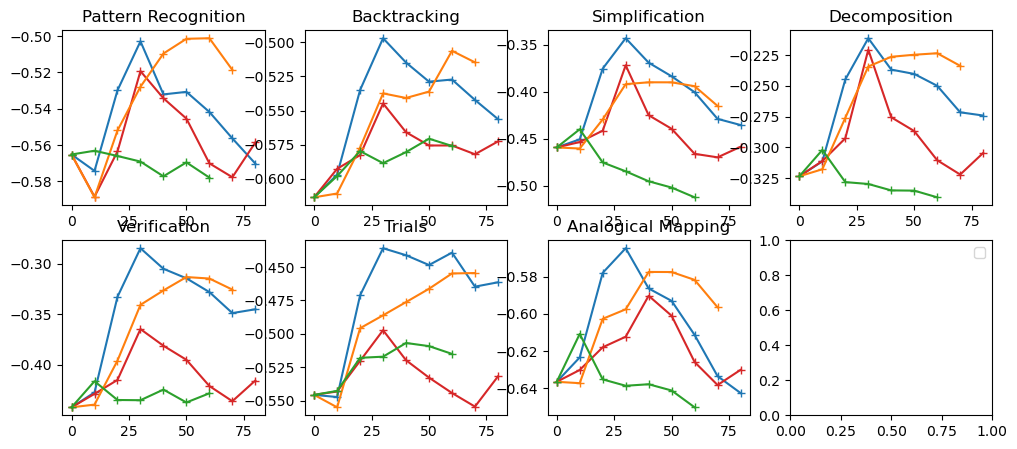

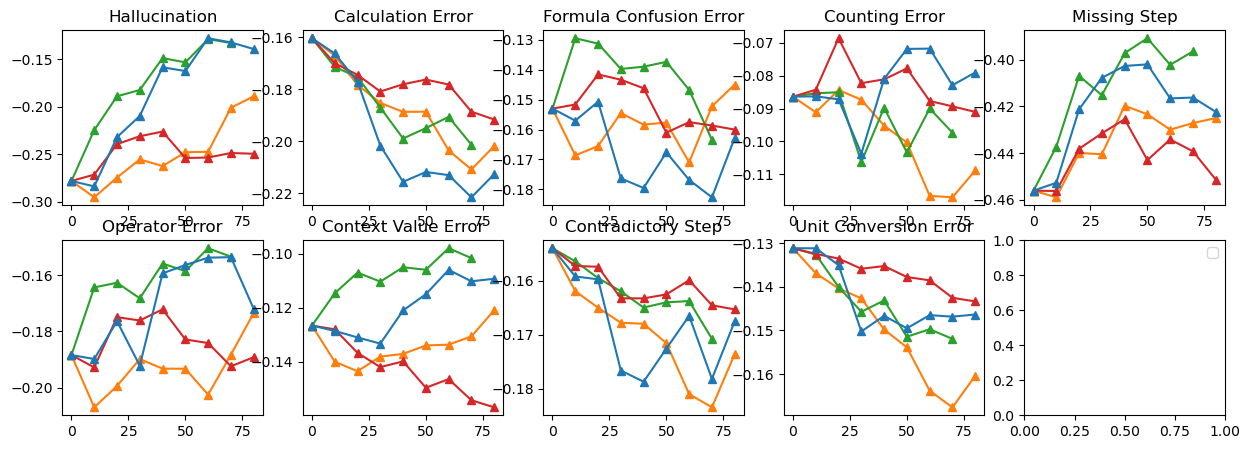

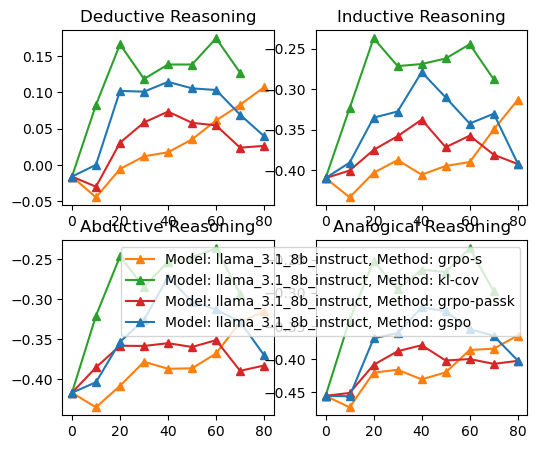

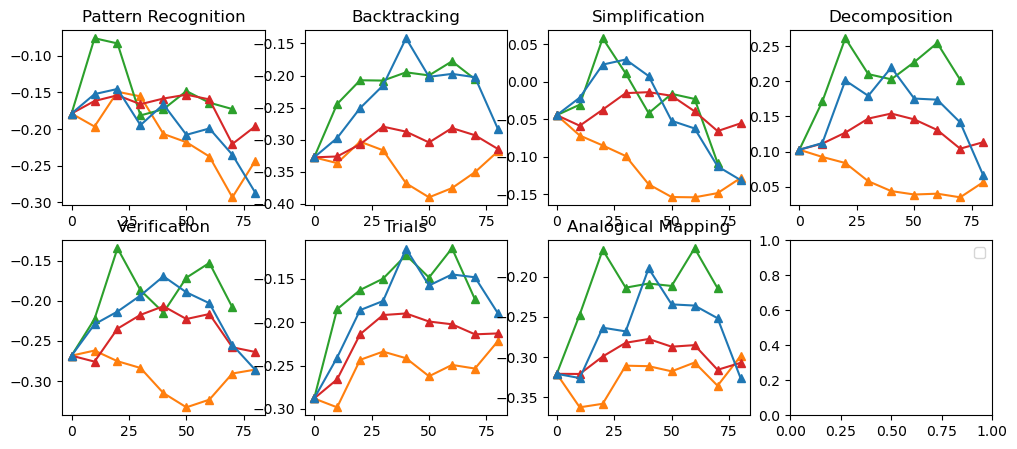

In [30]:
for model in models:
    binned = binnings_old(deltas)
    processed = preprocess(binned, models=[model])
    for taxonomy, data in processed.items():
        plot_helper(data)

In [8]:
# repeating the correlation plots from the prelim experiments
from util import rollouts

In [31]:
# preprocess rollouts for correlation analysis
# we'll collect [method pass@1] values
vs = rollouts(recompute=False)

In [32]:
def preprocess_rollouts(vs : dict) -> dict:
    ret = defaultdict()

    for method, checkpoints in vs.items():
        pass1 : list[float|np.float32] = []
        debug_cp = 0
        for cp, datasets in checkpoints.items():
            curcp = int(cp)
            if debug_cp > curcp:
                raise ValueError("Checkpoint sorting off.")
            debug_cp = curcp
            pass1_cp : list[np.ndarray]= []
            for ds in datasets.values():
                pass1_cp.append(ds[:, 0]) # take pass@1 estimate.
            pass1.append(np.mean(np.concat(pass1_cp)))
        ret[method] = pass1
    return ret

In [33]:
pass1_values = preprocess_rollouts(vs)

In [34]:
processed['error_types']['Calculation Error']['qwen2.5_7b__grpo-passk']

[]

In [35]:
def correlations(
    processed: dict,
    pass1_permethod: dict,
):
    """
    For each taxonomy, plot a single heatmap:
        x-axis: method
        y-axis: behaviour
        color: correlation(delta, pass@1)
    """
    mapper = defaultdict()
    taxonomies = list(processed.keys())
    tmp = list(processed[taxonomies[0]].keys())[0]
    methods = sorted(list(processed[taxonomies[0]][tmp].keys()))

    for taxonomy, behaviours in processed.items():

        behaviour_names = sorted(behaviours.keys())
        corr_matrix = np.full(
            (len(behaviour_names), len(methods)),
            np.nan
        )

        for i, behaviour in enumerate(behaviour_names):
            for j, method in enumerate(methods):
                if method not in behaviours[behaviour]:
                    raise ValueError
        
                deltas = np.asarray(behaviours[behaviour][method])
                pass1 = np.asarray(pass1_permethod[method])

                if len(deltas) != len(pass1):
                    raise ValueError
        
                corr_matrix[i, j] = np.corrcoef(deltas, pass1)[0, 1]
        mapper[taxonomy] = corr_matrix

    for taxonomy, behaviours in processed.items():

        behaviour_names = sorted(behaviours.keys())

        # ---- plotting ----
        fig, ax = plt.subplots(
            figsize=(1.2 * len(methods), 0.6 * len(behaviour_names))
        )

        im = ax.imshow(mapper[taxonomy], vmin=-1, vmax=1)

        ax.set_xticks(range(len(methods)))
        ax.set_xticklabels(methods, rotation=45, ha="right")
        ax.set_yticks(range(len(behaviour_names)))
        ax.set_yticklabels(behaviour_names)

        ax.set_xlabel("Method")
        ax.set_ylabel("Behaviour")
        ax.set_title(f"Δ logprob ↔ pass@1 corr — {taxonomy}")

        fig.colorbar(im, ax=ax, label="Pearson correlation")
        plt.show()

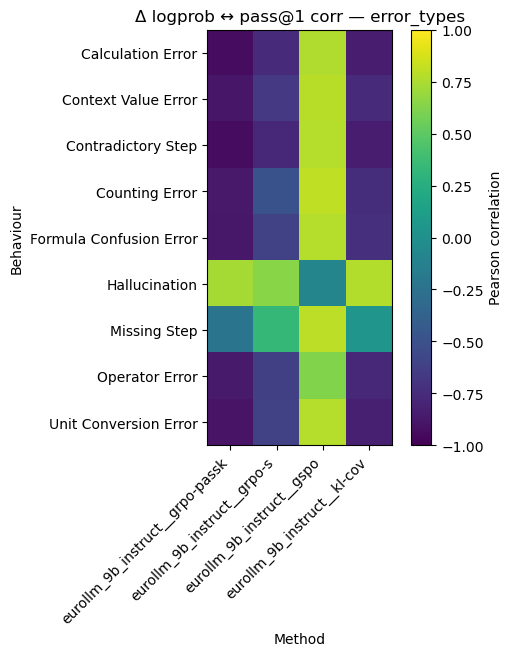

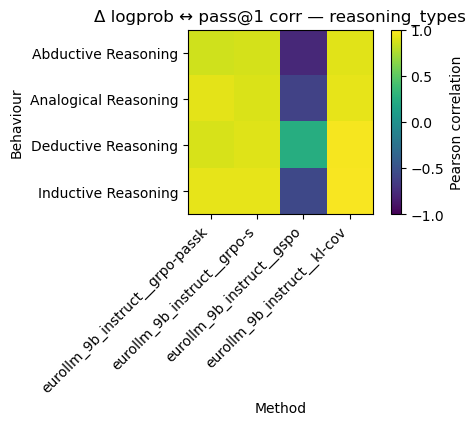

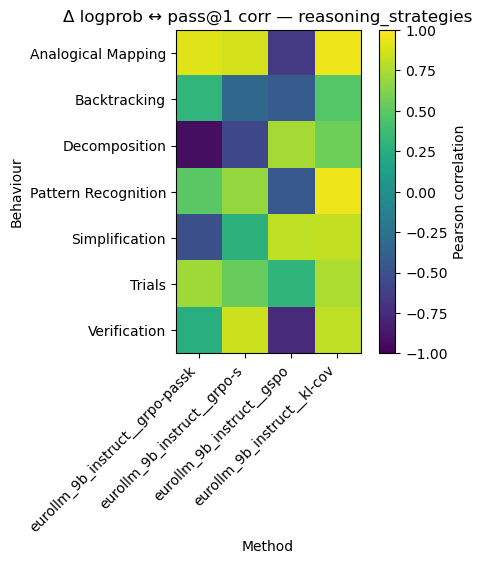

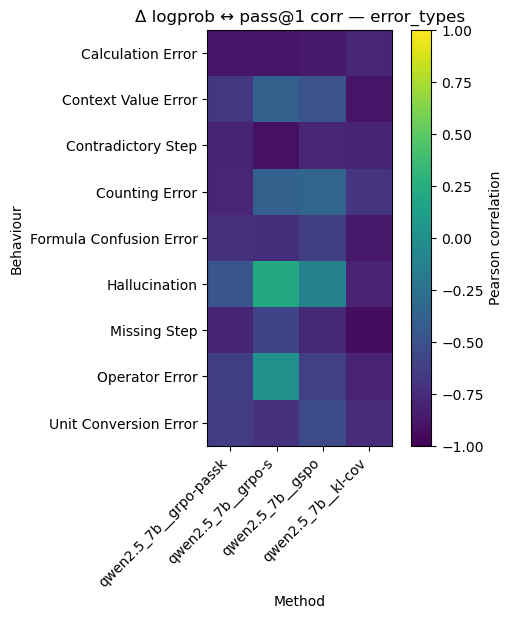

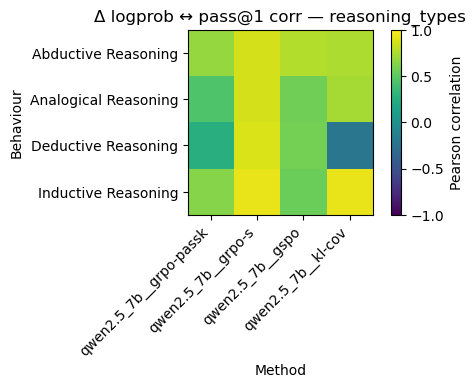

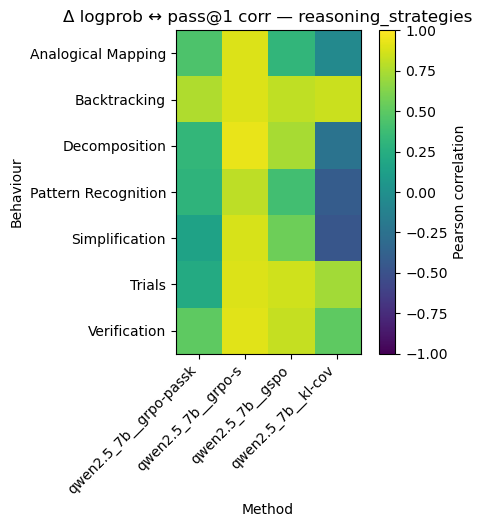

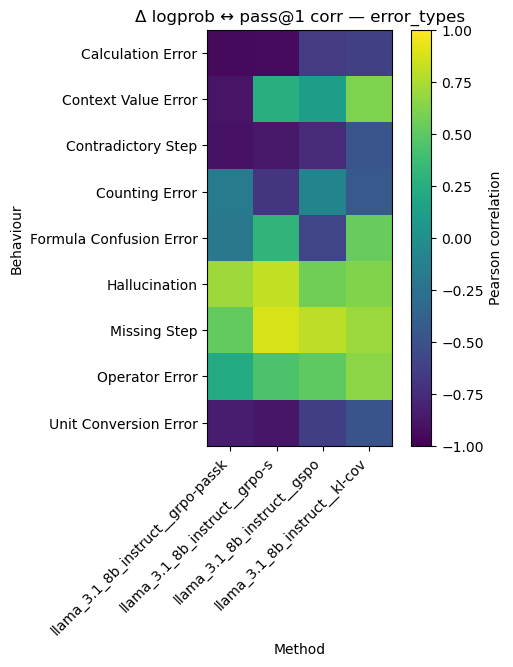

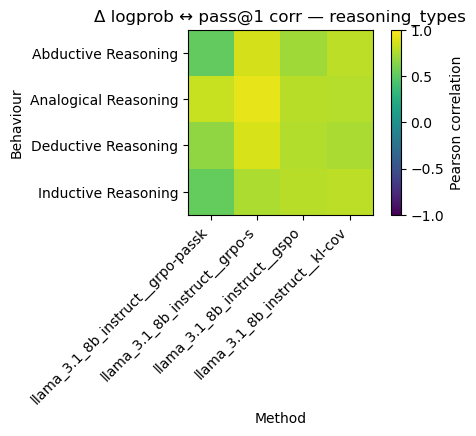

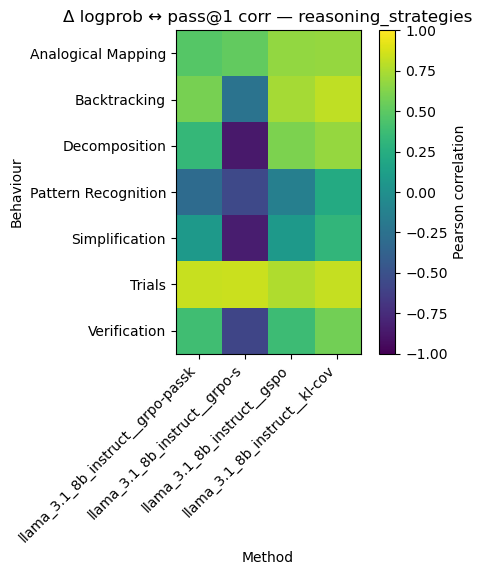

In [36]:
for model in models:
    binned = binnings_old(deltas)
    processed = preprocess(binned, models=[model])
    correlations(processed=processed, pass1_permethod=pass1_values)